# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [4]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [5]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [6]:
# Change this to the path where you unzipped the dataset
dataset_root = "./data"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

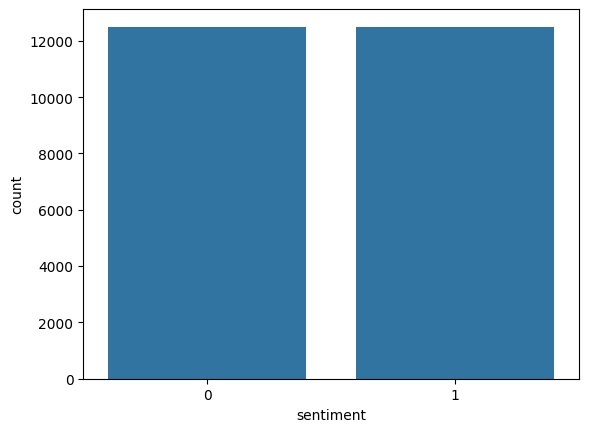

In [7]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [8]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


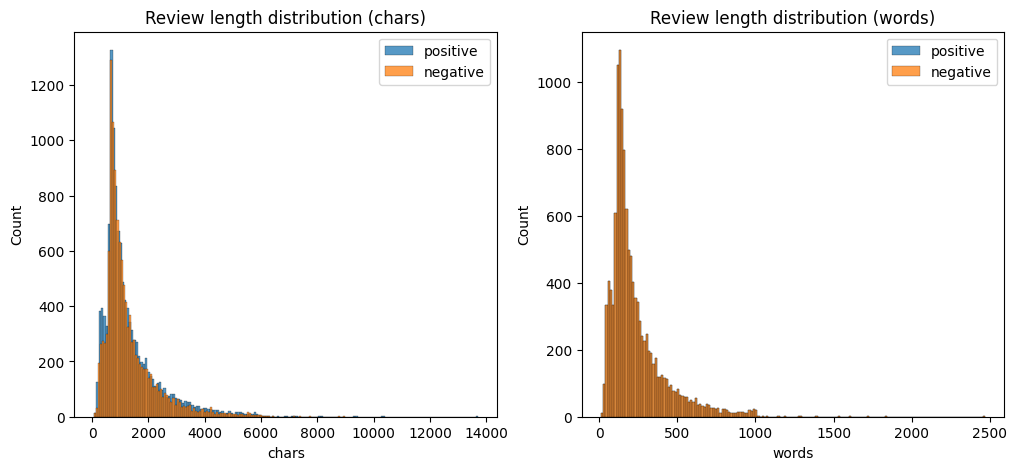

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

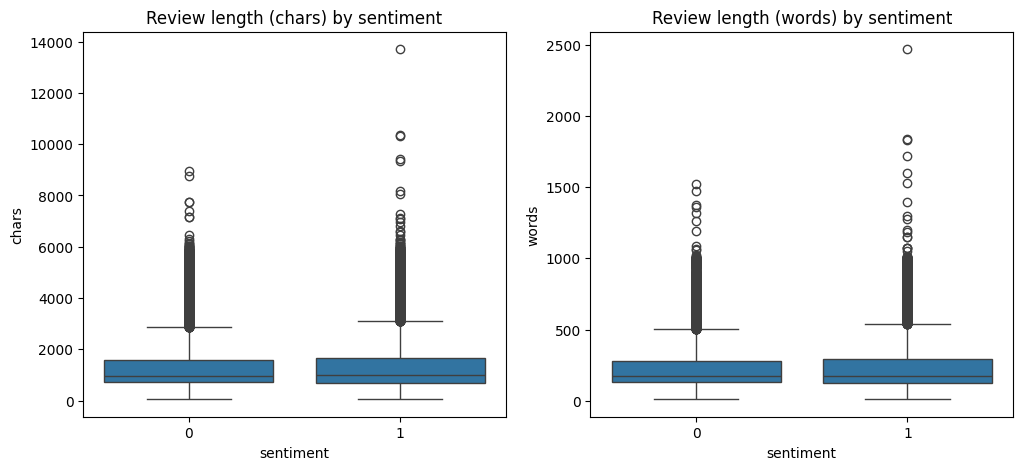

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [11]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [12]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [13]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [17]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [18]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [19]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [21]:
print(train_df['review'][0])
print(x_train[0])

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 58 stored elements and shape (1, 74726)>
  Coords	Values
  (0, 9230)	4
  (0, 30858)	5
  (0, 10826)	1
  (0, 13474)	1
  (0, 53350)	1
  

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [22]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(646, 1), (1917, 1), (2150, 1), (6702, 1), (9230, 4), (9744, 1), (10826, 1), (12652, 1), (12911, 1), (13474, 1), (22187, 1), (23093, 1), (23754, 1), (24297, 1), (24591, 1), (30858, 5), (32680, 1), (33770, 1), (33811, 1), (34592, 1), (36809, 1), (38022, 1), (38627, 1), (38815, 1), (40771, 1), (44180, 1), (46864, 1), (48620, 1), (49455, 1), (50078, 1), (50671, 1), (51797, 1), (51856, 1), (53350, 1), (53748, 1), (53885, 1), (54710, 1), (54872, 1), (55749, 1), (56943, 1), (57502, 1), (57614, 1), (57947, 2), (57968, 1), (58140, 1), (58506, 1), (60414, 1), (63684, 2), (63685, 2), (64599, 1), (65664, 4), (65666, 1), (66431, 1), (66827, 1), (68045, 1), (72437, 1), (72797, 1), (74040, 1)]


The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [23]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

35: 1
adults: 1
age: 1
believe: 1
bromwell: 4
burn: 1
cartoon: 1
classic: 1
closer: 1
comedy: 1
episode: 1
expect: 1
far: 1
fetched: 1
financially: 1
high: 5
immediately: 1
insightful: 1
inspector: 1
isn: 1
knew: 1
lead: 1
life: 1
line: 1
many: 1
much: 1
one: 1
pathetic: 1
pettiness: 1
pity: 1
pomp: 1
profession: 1
programs: 1
ran: 1
reality: 1
recalled: 1
remind: 1
repeatedly: 1
right: 1
sack: 1
satire: 1
saw: 1
school: 2
schools: 1
scramble: 1
see: 1
situation: 1
student: 2
students: 2
survive: 1
teachers: 4
teaching: 1
think: 1
time: 1
tried: 1
welcome: 1
whole: 1
years: 1


One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [25]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were once considered human who did everything from going to school, work, or vote for the matter. Most people think of the homeless as just a lost cause while worrying about things such as racism, the war on Iraq, pressuring kids to succeed, technology, the elections, inflation, or worrying if they'll be next to end up on the streets.<br /><br />But what if you were given a bet to live on the streets for a month without the luxuries you once had from a home, the entertainment sets, a bathroom, pictures on the wall, a computer, and everything you once treasure to see what it's like to be homeless? That is Goddard Bolt's lesson.<br /><br />Mel Brooks (who directs) who stars as Bolt plays a rich man who has everything in the world until deciding to make a bet with a sissy rival (Jeffery Tambor) to see if he can live in the streets for thir

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [27]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [28]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86356,0.998480,0.869742,0.99816,0.85520,0.998320,0.862410


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [29]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.197),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

First, according to NLTK documentation, we must download the dependencies to use.

In [30]:
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

Then, we can create the stemmer and lemmatizer we will be using in the preprocessing step prior to normalization on all four experiments. We will be using `PorterStemmer` as per the class presentation, and `WordNetLemmatizer` as per [IBM](https://www.ibm.com/think/topics/stemming-lemmatization) documentation. We will not be using `spacy` in accordance with the class presentation because it is much more robust and training time skyrocketted.

In [31]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import word_tokenize, pos_tag

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

Because we are using `WordNetLemmatizer`, we have to get the Part-Of-Speech tags (`pos-tags`) of each token. To do this, we can make our own function to map the extracted tag to the static enum tag in the WordNet library.

We can then make our `stem_text` and `lemmatize_text` functions.

In [32]:
def stem_text(text):
    text = ' '.join([stemmer.stem(w) for w in text.split()])
    return normalize_text(text)

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_text(text):
    words = word_tokenize(text)
    pos_tags = pos_tag(words)
    text = ' '.join([lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags])
    return normalize_text(text)

Now, let's define our experiments as we did earlier in the notebook. Each one of them calls `normalize` AFTER applying the preprocessing step.

In [33]:
# copied from above
experiments = [
    ('CountVectorizer-stem', stem_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-lemma', lemmatize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-stem', stem_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-lemma', lemmatize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

Then, let's run the experiments and print the model metrics.

In [34]:
results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df

,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
3,TfidfVectorizer-lemma,0.93216,0.87700,0.924886,0.876789,0.94072,0.87728,0.932736,0.877034
2,TfidfVectorizer-stem,0.93164,0.87664,0.925278,0.876038,0.93912,0.87744,0.932148,0.876739
1,CountVectorizer-lemma,0.99728,0.86108,0.997200,0.869142,0.99736,0.85016,0.997280,0.859546
0,CountVectorizer-stem,0.99792,0.85968,0.998319,0.862990,0.99752,0.85512,0.997919,0.859037


Finally, print the top-most and bottom-most features.

In [35]:
print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,excellent (1.688),erotic (1.543),great (7.380),great (7.320)
#2,flawless (1.526),flawless (1.509),excel (5.693),excellent (6.334)
#3,units (1.401),squirrel (1.438),love (5.366),love (5.010)
#4,superb (1.379),superb (1.425),best (5.055),best (4.851)
#5,refresh (1.359),refresh (1.349),enjoy (4.969),perfect (4.827)
#6,funniest (1.290),whoopi (1.319),perfect (4.858),favorite (4.613)
#7,favorit (1.284),excellent (1.318),favorit (4.417),wonderful (4.603)
#8,milligan (1.279),wonderfully (1.300),well (4.109),enjoy (4.493)
#9,excel (1.266),vengeance (1.278),fun (3.952),fun (3.952)



Top 10 negative words across experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,awful (-2.269),disappointment (-2.096),worst (-9.304),bad (-10.577)
#2,worst (-2.050),poorly (-1.828),bad (-7.612),waste (-7.391)
#3,poorli (-1.924),mstk (-1.697),wast (-7.414),awful (-6.452)
#4,disappointment (-1.782),waste (-1.672),poor (-5.518),boring (-5.489)
#5,wast (-1.694),awful (-1.616),bore (-5.414),poor (-5.308)
#6,mstk (-1.598),disappointing (-1.546),noth (-5.141),nothing (-4.960)
#7,terrible (-1.425),baldwin (-1.513),awful (-4.598),terrible (-4.731)
#8,forgett (-1.382),unfunny (-1.477),aw (-4.559),no (-4.572)
#9,bore (-1.378),boring (-1.473),no (-4.543),horrible (-4.350)


#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

The vectorizer + preprocessing combination that yields the best performance is `TfidfVectorizer-lemma`. Despite a lower training accuracy and lower recall and precision, its test accuracy and f1-score were the highest, indicating a good model performance on never-before-seen data and a good balance between precision and recall, despite lower individual metrics on those, particularily. `CountVectorizer` models appeared to also overfit, as indicated by their training accuracy and poor test performance.

Additionally, some interesting differences in the top features across the different models are:
- `TF-IDF` ranks cleaner words like *great, love best, worst, bad*, whereas `CountVectorizer` includes dataset-specific words like *squirrel* and *whoopi*.
- Lemmatization produces natural words like *wonderful, disappointment*, while stemming creates truncated forms like *beauti* (beautiful) and *noth* (nothing).
- Top words are consistent across the board: *great, excellenmt, love, best, worst, bad, awful*.

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

First, we define the review and get the best model from the result data frame.

*NOTE: The review was written with ChatGPT*

In [ ]:
review_text = "I just watched this movie and it was absolutely fantastic. The performances were brilliant, the story kept me hooked, and the cinematography was stunning. I would highly recommend it to anyone who loves great cinema."

# this particular line was generated by Copilot
best_model_name = results_df.iloc[0]['vectorizer']

Then, from the chosen best model, we can select its latest run to get the vectorizer and process our text. Otherwise, we can't call the model without the preprocessing step, with the raw input.

In [37]:
best_model_run = None
for run in model_runs:
    if run['name'] == best_model_name:
        best_model_run = run
        break

Then, assuming a `stem` or `lemmatization` model, we vectorize the preprocessed text using the model run from the best model. 

We then make a prediction using that vectorized text.

In [38]:
if 'stem' in best_model_name:
    processed_text = stem_text(review_text)
else:
    processed_text = lemmatize_text(review_text)

vectorized_text = best_model_run['fitted_vectorizer'].transform([processed_text])

prediction = best_model_run['model'].predict(vectorized_text)[0]

Finally, we parse the results.

In [39]:
print("Best model:", best_model_name)

if prediction == 1:
    print("Predicted sentiment: positive")
else:
    print("Predicted sentiment: negative")

Best model: TfidfVectorizer-lemma
Predicted sentiment: positive


I agree with the model's prediction. This is because my review included words like *fantastic* and *brilliant*. Despite them not being on the top features for the lemmatizer TF-IDF vectorizer model, it makes sense that it had an accurate prediction because it was the best model at generalizing. Additionally, I believe the word *great* toward the end of the review helped a lot with the prediction, as that is the highest-ranked feature on TF-IDF. 

#### Write your final remarks on this activity.

Finally, some final remarks can be made from the exercise in this notebook, particularily, the activity with the four experiments:
- TF-IDF beat CountVectorizer in terms of test accuracy, despite worsenned results in individual metrics. This means that TF-IDF was better at generalizing.
- CountVectorizing was overfitting, indicated by its almost perfect training accuracy. This threw our results off and was a big reason why individual metrics were so skewed.
- Some top features overlap a lot (like *great, worst, bad*).
- Some dataset-specific words leaked into the top features, like *squirrel, baldwin*, particularily in CountVectorizer. This is probably another indicator of overfitting.

Between stemming and lemmatization:
- Lemmatization was absolutely better than stemming. Because of it's context-based analysis, it was able to perform better. However, because of POS tagging, our runtime was exponentially higher. For smaller-sized exercises, stemming might be more benefitial. For production-level environemnts, lemmatization will be better for model performance.
- Some features produced by stemming were unreadable, like `beauti` or `wast`. Unsure on whether this actually matters to the model or not, but it might, as they can probably be inferred to be something else entirely.